# 01 — Build the Training Dataset

**Purpose:** produce a single labeled CSV that notebook `02_train_classifier.ipynb` consumes.

## Why this notebook exists

The uploaded corpus (`archive/Resume/Resume.csv`, 2,484 real resumes) is labeled by **broad industry** — `ACCOUNTANT`, `AVIATION`, `BANKING`, `INFORMATION-TECHNOLOGY`, … It has **no tech-role granularity**, so nothing in it can teach a model to separate a *Data Engineer* from a *Backend Developer*.

This notebook fills that gap by generating synthetic resumes for **10 tech roles** and merging them with the real corpus.

## How the synthetic data avoids being useless

Template-generated data invites a model to learn *the template* instead of *the role*. Three mitigations are built in:

| Risk | Mitigation |
|---|---|
| Model detects "synthetic" by shape/length | Generated resumes copy the real corpus's section layout and are sampled into its word-count range (~620–980 words vs. real mean ~811) |
| Classes trivially separable by disjoint skill lists | ~30% of resumes borrow an adjacent role's skills via `ADJACENT_ROLES` (a Backend Developer listing Docker and SQL is realistic) |
| Fixed template detectable | Randomized section order/presence, date formats, bullet markers, seniority prefixes, company/university/city pools |

**This does not make synthetic data equal to real data.** Metrics on the synthetic classes remain an upper bound — notebook 02 reports real-only and synthetic-only scores separately for exactly this reason.

**Output:** `backend/ml/data/merged_resumes.csv`

## 0. Setup

In [1]:
import random
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)

# This notebook lives at backend/ml/ -> repo root is two levels up.
REPO_ROOT = Path.cwd().resolve().parents[1]
REAL_CSV = REPO_ROOT / "archive" / "Resume" / "Resume.csv"
DATA_DIR = REPO_ROOT / "backend" / "ml" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = DATA_DIR / "merged_resumes.csv"

print("Repo root:  ", REPO_ROOT)
print("Real CSV:   ", REAL_CSV, "| exists:", REAL_CSV.exists())
print("Output CSV: ", OUTPUT_CSV)

Repo root:   C:\Users\Asus Vivobook\Resume_parsing
Real CSV:    C:\Users\Asus Vivobook\Resume_parsing\archive\Resume\Resume.csv | exists: True
Output CSV:  C:\Users\Asus Vivobook\Resume_parsing\backend\ml\data\merged_resumes.csv


## 1. Role profiles

Each role carries its own job titles, core/secondary skill pools, responsibility and achievement bullet templates, projects, and certifications. `ADJACENT_ROLES` at the bottom defines which roles realistically share vocabulary — that map drives the deliberate class overlap.

In [2]:

import random
from dataclasses import dataclass, field

# --------------------------------------------------------------------------
# Shared pools
# --------------------------------------------------------------------------

FIRST_NAMES = (
    "Aarav Priya Rohan Neha Arjun Sneha Vikram Ananya Karan Divya Rahul Meera "
    "James Sarah Michael Emily David Jessica Daniel Laura Chris Amanda Kevin "
    "Wei Yuki Chen Hiroshi Sofia Lucas Mateo Elena Omar Fatima Ahmed Layla"
).split()

LAST_NAMES = (
    "Sharma Patel Reddy Nair Iyer Desai Kapoor Mehta Rao Gupta Singh Joshi "
    "Smith Johnson Williams Brown Jones Garcia Miller Davis Wilson Anderson "
    "Zhang Tanaka Kim Rossi Silva Muller Dubois Novak Petrov Hassan Khan"
).split()

CITIES = (
    "Bengaluru, KA|Hyderabad, TS|Pune, MH|Mumbai, MH|Chennai, TN|Noida, UP|"
    "San Francisco, CA|Seattle, WA|Austin, TX|New York, NY|Boston, MA|"
    "Denver, CO|Chicago, IL|Atlanta, GA|Toronto, ON|London, UK|Berlin, DE|"
    "Remote"
).split("|")

COMPANIES = (
    "Infosys|TCS|Wipro|Accenture|Cognizant|Capgemini|HCL Technologies|"
    "Amazon|Microsoft|Google|Meta|Netflix|Uber|Airbnb|Stripe|Salesforce|"
    "Oracle|IBM|Adobe|Intuit|PayPal|Walmart Labs|Flipkart|Swiggy|Zomato|"
    "Razorpay|Freshworks|Zoho|Postman|BrowserStack|Nutanix|VMware|"
    "Deloitte Digital|ThoughtWorks|Publicis Sapient|Optum|Cisco|Qualcomm|"
    "CloudScale Systems|DataBridge Analytics|NorthStar Software|"
    "Vertex Labs|Quantum Retail|Helix Health Tech|Orbit Fintech"
).split("|")

UNIVERSITIES = (
    "Indian Institute of Technology|National Institute of Technology|"
    "Birla Institute of Technology and Science|Delhi Technological University|"
    "Vellore Institute of Technology|Manipal Institute of Technology|"
    "Anna University|Pune University|Gujarat Technological University|"
    "L.D. College of Engineering|Stanford University|Carnegie Mellon University|"
    "University of Illinois|Georgia Institute of Technology|"
    "University of Texas at Austin|Arizona State University|"
    "University of Toronto|Technical University of Munich"
).split("|")

DEGREES = (
    "Bachelor of Technology|B.Tech|Bachelor of Engineering|B.E|"
    "Master of Technology|M.Tech|Master of Science|M.Sc|"
    "Bachelor of Science|B.Sc|Master of Computer Applications|MCA"
).split("|")

FIELDS_OF_STUDY = (
    "Computer Science|Computer Engineering|Information Technology|"
    "Software Engineering|Electronics and Communication|Data Science|"
    "Computer Science and Engineering|Information Systems"
).split("|")

MONTHS = (
    "January February March April May June July August September October "
    "November December"
).split()

MONTHS_ABBR = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()

BULLET_MARKERS = ("•", "-", "*", "●", "")

SENIORITY_PREFIXES = ("", "", "Senior ", "Lead ", "Junior ", "Staff ", "Principal ")

DOMAINS = (
    "e-commerce|fintech|healthcare|logistics|ed-tech|travel|media streaming|"
    "insurance|retail|B2B SaaS|gaming|telecom|supply chain|ad-tech"
).split("|")


# --------------------------------------------------------------------------
# Role profiles
# --------------------------------------------------------------------------


@dataclass
class RoleProfile:
    """Everything needed to generate one role's resumes."""

    label: str
    titles: tuple[str, ...]
    core_skills: tuple[str, ...]
    secondary_skills: tuple[str, ...]
    responsibilities: tuple[str, ...]
    achievements: tuple[str, ...]
    projects: tuple[tuple[str, str], ...]  # (name, description)
    certifications: tuple[str, ...] = field(default=())


ROLE_PROFILES: dict[str, RoleProfile] = {
    "DATA-ENGINEER": RoleProfile(
        label="DATA-ENGINEER",
        titles=(
            "Data Engineer",
            "Big Data Engineer",
            "ETL Developer",
            "Data Platform Engineer",
            "Analytics Engineer",
        ),
        core_skills=(
            "Apache Spark", "Hadoop", "Apache Airflow", "Kafka", "SQL", "Python",
            "Snowflake", "dbt", "Redshift", "BigQuery", "Databricks", "Hive",
            "ETL", "Data Warehousing", "Data Modeling", "PySpark",
        ),
        secondary_skills=(
            "AWS Glue", "Delta Lake", "Presto", "Flink", "Scala", "Parquet",
            "Avro", "Sqoop", "Luigi", "Great Expectations", "Terraform",
            "Docker", "Kubernetes", "PostgreSQL", "MongoDB", "Cassandra",
            "Star Schema", "Slowly Changing Dimensions", "CDC",
        ),
        responsibilities=(
            "Designed and maintained batch and streaming ETL pipelines processing over {volume} of {domain} data daily using Apache Spark and Airflow.",
            "Built dimensional data models and star schemas in Snowflake, reducing analyst query times by {pct}%.",
            "Implemented Kafka-based change data capture pipelines to replicate transactional data into the warehouse in near real time.",
            "Migrated legacy on-premise Hadoop workloads to Databricks on AWS, cutting infrastructure spend by {pct}%.",
            "Authored dbt models and automated data quality tests, catching schema drift before it reached downstream dashboards.",
            "Partitioned and bucketed Hive tables to optimize scan performance across multi-terabyte fact tables.",
            "Orchestrated over {count} interdependent Airflow DAGs with SLA monitoring and automated backfill support.",
            "Optimized PySpark jobs by tuning shuffle partitions and broadcast joins, reducing cluster runtime from hours to minutes.",
            "Established data lineage and cataloging practices so downstream teams could trace every metric to its source system.",
            "Partnered with analytics and data science teams to expose curated datasets through a governed semantic layer.",
            "Developed incremental ingestion frameworks handling late-arriving and out-of-order events idempotently.",
            "Built monitoring and alerting for pipeline freshness and row-count anomalies using custom Prometheus metrics.",
        ),
        achievements=(
            "Reduced daily pipeline runtime from {hours} hours to under {mins} minutes through partition pruning and join optimization.",
            "Cut cloud data warehouse costs by {pct}% by introducing incremental models and result caching.",
            "Delivered a unified customer data platform consolidating {count} fragmented source systems.",
            "Achieved {pct}% pipeline reliability across a fleet of production DAGs over four consecutive quarters.",
        ),
        projects=(
            ("Real-Time Clickstream Pipeline", "Streaming ingestion pipeline built with Kafka, Spark Structured Streaming, and Delta Lake, serving sub-minute freshness dashboards."),
            ("Warehouse Migration Framework", "Automated migration tooling that ported legacy SQL Server ETL jobs to Snowflake with dbt, including reconciliation testing."),
            ("Data Quality Service", "Rule-driven validation layer using Great Expectations that gates pipeline promotion between staging and production."),
            ("Lakehouse Cost Optimizer", "Job profiling utility that identifies expensive Spark stages and recommends partitioning strategies."),
        ),
        certifications=(
            "AWS Certified Data Analytics – Specialty",
            "Databricks Certified Data Engineer Professional",
            "Google Cloud Professional Data Engineer",
            "SnowPro Core Certification",
        ),
    ),
    "BACKEND-DEVELOPER": RoleProfile(
        label="BACKEND-DEVELOPER",
        titles=(
            "Backend Developer",
            "Backend Engineer",
            "Software Engineer - Backend",
            "Server-Side Developer",
            "API Developer",
        ),
        core_skills=(
            "Java", "Python", "Spring Boot", "FastAPI", "Django", "Node.js",
            "REST", "GraphQL", "PostgreSQL", "MySQL", "Redis", "Microservices",
            "gRPC", "JUnit", "Pytest", "Hibernate",
        ),
        secondary_skills=(
            "Docker", "Kubernetes", "RabbitMQ", "Kafka", "Nginx", "Celery",
            "SQLAlchemy", "MongoDB", "Elasticsearch", "OAuth2", "JWT",
            "Swagger", "Maven", "Gradle", "Git", "Jenkins", "AWS", "Linux",
        ),
        responsibilities=(
            "Designed and shipped RESTful microservices handling {rps} requests per second for a {domain} platform.",
            "Reduced p99 API latency by {pct}% through query optimization, connection pooling, and Redis caching.",
            "Led the decomposition of a monolithic application into {count} independently deployable services.",
            "Implemented idempotent payment processing workflows with distributed transaction guarantees.",
            "Built event-driven integrations with Kafka to decouple order, inventory, and notification services.",
            "Authored comprehensive integration test suites raising backend coverage from {low}% to {pct}%.",
            "Designed normalized PostgreSQL schemas and wrote migration scripts supporting zero-downtime deploys.",
            "Introduced structured logging, request tracing, and health endpoints across all owned services.",
            "Implemented role-based access control and OAuth2 token flows for a multi-tenant API.",
            "Reviewed pull requests and mentored {count} junior engineers on clean architecture and testing practices.",
            "Containerized services with Docker and defined Kubernetes manifests with resource limits and probes.",
            "Profiled and eliminated N+1 query patterns in the ORM layer, cutting database load substantially.",
        ),
        achievements=(
            "Scaled the core order service to handle {pct}% year-over-year traffic growth without adding infrastructure.",
            "Cut average API response time from {hours}00ms to under {mins}0ms across the top ten endpoints.",
            "Delivered a public API consumed by {count} external partner integrations.",
            "Reduced production incident count by {pct}% after introducing contract testing and staged rollouts.",
        ),
        projects=(
            ("Resume Parsing Service", "FastAPI backend with async SQLAlchemy that ingests PDF resumes, extracts structured entities, and exposes a searchable paginated API."),
            ("Inventory Reconciliation API", "Spring Boot service reconciling warehouse stock against order events with exactly-once processing semantics."),
            ("Multi-Tenant Auth Gateway", "Centralized authentication service issuing scoped JWTs with refresh-token rotation and audit logging."),
            ("Notification Dispatcher", "Queue-backed fan-out service delivering email, SMS, and push notifications with retry and dead-letter handling."),
        ),
        certifications=(
            "Oracle Certified Professional, Java SE Programmer",
            "AWS Certified Developer – Associate",
            "Certified Kubernetes Application Developer (CKAD)",
        ),
    ),
    "FRONTEND-DEVELOPER": RoleProfile(
        label="FRONTEND-DEVELOPER",
        titles=(
            "Frontend Developer",
            "Frontend Engineer",
            "UI Developer",
            "React Developer",
            "Web Developer",
        ),
        core_skills=(
            "React", "JavaScript", "TypeScript", "HTML", "CSS", "Redux",
            "Next.js", "Tailwind CSS", "SASS", "Webpack", "Vue", "Angular",
            "Jest", "Cypress", "Responsive Design", "Accessibility",
        ),
        secondary_skills=(
            "Vite", "Storybook", "React Query", "Zustand", "Figma", "Framer Motion",
            "GraphQL", "REST", "Git", "Jira", "Bootstrap", "Material UI",
            "Lighthouse", "Web Vitals", "PWA", "i18n", "Node.js",
        ),
        responsibilities=(
            "Built responsive, accessible React interfaces serving {count}00K monthly active users on a {domain} product.",
            "Improved Lighthouse performance score from {low} to {pct} through code splitting, lazy loading, and image optimization.",
            "Migrated a legacy jQuery codebase to a component-driven React and TypeScript architecture.",
            "Established a shared component library in Storybook, adopted by {count} product teams.",
            "Implemented state management with Redux Toolkit, simplifying data flow across deeply nested views.",
            "Collaborated closely with designers in Figma to translate mockups into pixel-accurate components.",
            "Reduced main-bundle size by {pct}% via tree shaking, dynamic imports, and dependency audits.",
            "Wrote unit and end-to-end tests with Jest and Cypress, raising frontend coverage to {pct}%.",
            "Ensured WCAG 2.1 AA compliance through semantic markup, keyboard navigation, and screen-reader testing.",
            "Integrated REST and GraphQL APIs with optimistic updates and robust error/loading states.",
            "Set up CI checks for type safety, linting, and visual regression on every pull request.",
            "Implemented dark mode theming with CSS custom properties across the entire design system.",
        ),
        achievements=(
            "Increased conversion rate by {pct}% after rebuilding the checkout flow with performance and accessibility in mind.",
            "Cut time-to-interactive from {hours} seconds to under {mins} seconds on mid-range mobile devices.",
            "Shipped a design system consumed by {count} internal applications.",
            "Reduced UI defect escape rate by {pct}% through automated visual regression testing.",
        ),
        projects=(
            ("Resume Parsing Dashboard", "React and Vite frontend with drag-and-drop upload, parsed-entity views, faceted search, and Tailwind-based theming."),
            ("Analytics Console", "Data-dense dashboard with virtualized tables, chart drill-downs, and saved filter presets."),
            ("Component Design System", "Accessible, themeable component library documented in Storybook with automated a11y checks."),
            ("Progressive Web Storefront", "Offline-capable PWA storefront with service-worker caching and installable app shell."),
        ),
        certifications=(
            "Meta Front-End Developer Professional Certificate",
            "Google Mobile Web Specialist",
            "W3C Front-End Web Developer",
        ),
    ),
    "FULLSTACK-DEVELOPER": RoleProfile(
        label="FULLSTACK-DEVELOPER",
        titles=(
            "Full Stack Developer",
            "Full Stack Engineer",
            "Software Engineer - Full Stack",
            "MERN Stack Developer",
            "Application Developer",
        ),
        core_skills=(
            "React", "Node.js", "Express", "TypeScript", "JavaScript", "Python",
            "Django", "MongoDB", "PostgreSQL", "REST", "GraphQL", "Next.js",
            "Docker", "Git", "HTML", "CSS",
        ),
        secondary_skills=(
            "Redux", "Tailwind CSS", "FastAPI", "Prisma", "Sequelize", "Redis",
            "AWS", "Firebase", "Jest", "Cypress", "Nginx", "CI/CD", "Jira",
            "Socket.IO", "Stripe API", "OAuth2",
        ),
        responsibilities=(
            "Owned features end to end — database schema, API endpoints, and React UI — for a {domain} product.",
            "Built and deployed full-stack applications with React frontends and Node.js/Express backends serving {count}0K users.",
            "Designed MongoDB and PostgreSQL schemas balancing normalized integrity with read performance.",
            "Implemented real-time collaboration features using WebSockets and optimistic client-side updates.",
            "Integrated third-party payment, mapping, and authentication providers with graceful failure handling.",
            "Containerized the full stack with Docker Compose, standardizing local development across the team.",
            "Set up CI/CD pipelines that lint, test, build, and deploy on every merge to main.",
            "Reduced page load time by {pct}% through server-side rendering with Next.js and API response caching.",
            "Wrote both backend integration tests and frontend end-to-end tests covering critical user journeys.",
            "Participated in product scoping, translating ambiguous requirements into technical designs and estimates.",
            "Refactored shared business logic into typed packages consumed by both web and mobile clients.",
            "Instrumented application analytics and error tracking to close the feedback loop on releases.",
        ),
        achievements=(
            "Single-handedly delivered an MVP from empty repository to production in under {mins} weeks.",
            "Grew a side project to {count}K registered users while maintaining {pct}% uptime.",
            "Reduced infrastructure cost by {pct}% by consolidating services and right-sizing containers.",
            "Shortened feature lead time from {hours} weeks to {mins} days by automating the release pipeline.",
        ),
        projects=(
            ("Full-Stack Resume Platform", "End-to-end resume parsing product: FastAPI backend, React frontend, PostgreSQL storage, and Dockerized deployment."),
            ("Collaborative Task Board", "Real-time Kanban application with WebSocket sync, role-based sharing, and offline conflict resolution."),
            ("Marketplace MVP", "Two-sided marketplace with Stripe payments, search, reviews, and an admin moderation console."),
            ("Personal Finance Tracker", "Budgeting application with bank-statement import, categorization rules, and trend visualizations."),
        ),
        certifications=(
            "freeCodeCamp Full Stack Development Certification",
            "AWS Certified Developer – Associate",
            "MongoDB Certified Developer Associate",
        ),
    ),
    "ML-ENGINEER": RoleProfile(
        label="ML-ENGINEER",
        titles=(
            "Machine Learning Engineer",
            "ML Engineer",
            "Applied Scientist",
            "Deep Learning Engineer",
            "MLOps Engineer",
        ),
        core_skills=(
            "Python", "PyTorch", "TensorFlow", "Scikit-learn", "MLflow", "Keras",
            "Machine Learning", "Deep Learning", "Natural Language Processing",
            "Computer Vision", "Feature Engineering", "Model Deployment",
            "Pandas", "NumPy", "Hugging Face", "ONNX",
        ),
        secondary_skills=(
            "Kubeflow", "SageMaker", "Vertex AI", "Airflow", "Docker", "Kubernetes",
            "FastAPI", "Spark", "Weights & Biases", "DVC", "Optuna", "XGBoost",
            "LightGBM", "OpenCV", "spaCy", "CUDA", "Triton",
        ),
        responsibilities=(
            "Trained and deployed production models for {domain} use cases, improving baseline accuracy by {pct}%.",
            "Built reproducible training pipelines with MLflow experiment tracking and DVC-versioned datasets.",
            "Deployed models as low-latency inference services behind FastAPI with autoscaling on Kubernetes.",
            "Engineered feature pipelines over Spark, cutting feature computation time by {pct}%.",
            "Implemented drift detection and automated retraining triggers for models in production.",
            "Fine-tuned transformer models for text classification and named entity recognition tasks.",
            "Ran systematic hyperparameter searches with Optuna across {count} experiment configurations.",
            "Quantized and exported models to ONNX, reducing inference latency by {pct}% on CPU targets.",
            "Established offline/online evaluation parity to catch training-serving skew before release.",
            "Partnered with data engineering to productionize feature stores backing multiple models.",
            "Wrote model cards documenting performance across demographic slices and known failure modes.",
            "Built A/B testing infrastructure to measure real-world model impact against business metrics.",
        ),
        achievements=(
            "Lifted recommendation click-through rate by {pct}% through a re-ranking model deployed to production.",
            "Reduced model inference cost by {pct}% via batching, quantization, and hardware right-sizing.",
            "Cut retraining cycle time from {hours} days to {mins} hours with an automated pipeline.",
            "Published {count} internal research notes adopted as standard practice across ML teams.",
        ),
        projects=(
            ("Resume Role Classifier", "TF-IDF and transformer-based classifier predicting a candidate's role from resume text, served through a REST inference endpoint."),
            ("Document Intelligence Pipeline", "OCR plus NER pipeline extracting structured fields from scanned documents at scale."),
            ("Demand Forecasting Model", "Gradient-boosted time-series model forecasting SKU-level demand with holiday and promotion features."),
            ("Semantic Search Engine", "Embedding-based retrieval service with approximate nearest-neighbour indexing and relevance evaluation harness."),
        ),
        certifications=(
            "TensorFlow Developer Certificate",
            "AWS Certified Machine Learning – Specialty",
            "Deep Learning Specialization – DeepLearning.AI",
            "Google Cloud Professional Machine Learning Engineer",
        ),
    ),
    "DATA-SCIENTIST": RoleProfile(
        label="DATA-SCIENTIST",
        titles=(
            "Data Scientist",
            "Senior Data Scientist",
            "Quantitative Analyst",
            "Decision Scientist",
            "Data Science Analyst",
        ),
        core_skills=(
            "Python", "R", "SQL", "Statistics", "Hypothesis Testing", "Pandas",
            "NumPy", "Scikit-learn", "Matplotlib", "Seaborn", "Tableau",
            "Power BI", "A/B Testing", "Regression Analysis", "Jupyter",
            "Predictive Modeling",
        ),
        secondary_skills=(
            "Machine Learning", "XGBoost", "Time Series", "Clustering",
            "Causal Inference", "Bayesian Methods", "Excel", "Looker",
            "Spark", "Databricks", "Airflow", "Git", "Survival Analysis",
            "Experiment Design", "Feature Engineering",
        ),
        responsibilities=(
            "Designed and analyzed A/B experiments informing {domain} product decisions worth {count} million in annual revenue.",
            "Built predictive churn models identifying at-risk customers with {pct}% precision at the top decile.",
            "Developed customer segmentation using clustering, enabling targeted retention campaigns.",
            "Translated ambiguous business questions into measurable hypotheses and analysis plans.",
            "Built executive dashboards in Tableau tracking north-star metrics and leading indicators.",
            "Performed causal impact analysis on marketing spend, reallocating budget toward higher-return channels.",
            "Automated recurring analyses with parameterized notebooks and scheduled SQL jobs.",
            "Presented findings and recommendations to non-technical stakeholders and executive leadership.",
            "Validated data quality assumptions upstream, catching instrumentation bugs that skewed key metrics.",
            "Built forecasting models for demand planning with confidence intervals and scenario analysis.",
            "Partnered with engineering to instrument new event tracking for previously unmeasurable behaviour.",
            "Established statistical guardrails and minimum detectable effect standards for the experimentation platform.",
        ),
        achievements=(
            "Identified a pricing inefficiency through cohort analysis that recovered {pct}% in lost margin.",
            "Reduced customer churn by {pct}% through a model-driven proactive outreach program.",
            "Cut reporting turnaround time from {hours} days to {mins} hours through automation.",
            "Ran {count} concurrent experiments per quarter as the analytics lead for the growth team.",
        ),
        projects=(
            ("Resume Corpus Analysis", "Exploratory analysis of a labeled resume corpus covering class balance, text-length outliers, and vocabulary overlap between categories."),
            ("Churn Prediction Study", "End-to-end churn modeling project with feature engineering, model comparison, and business impact quantification."),
            ("Pricing Elasticity Model", "Regression study estimating demand elasticity across product categories and regions."),
            ("Marketing Attribution Analysis", "Multi-touch attribution model comparing last-click against data-driven attribution."),
        ),
        certifications=(
            "Google Data Analytics Professional Certificate",
            "Microsoft Certified: Data Analyst Associate",
            "SAS Certified Data Scientist",
        ),
    ),
    "DEVOPS-ENGINEER": RoleProfile(
        label="DEVOPS-ENGINEER",
        titles=(
            "DevOps Engineer",
            "Site Reliability Engineer",
            "Platform Engineer",
            "Infrastructure Engineer",
            "Cloud Engineer",
        ),
        core_skills=(
            "Kubernetes", "Docker", "Terraform", "Ansible", "Jenkins", "AWS",
            "Azure", "GCP", "CI/CD", "Linux", "Bash", "Prometheus", "Grafana",
            "GitHub Actions", "Helm", "Nginx",
        ),
        secondary_skills=(
            "ArgoCD", "Vault", "Consul", "ELK Stack", "Datadog", "PagerDuty",
            "Python", "Go", "CloudFormation", "Packer", "Istio", "GitLab CI",
            "Kafka", "PostgreSQL", "Redis", "SLO", "Chaos Engineering",
        ),
        responsibilities=(
            "Managed production Kubernetes clusters running {count}00+ microservices for a {domain} platform.",
            "Automated infrastructure provisioning with Terraform modules, eliminating manual environment drift.",
            "Built CI/CD pipelines reducing average deployment time from {hours} hours to {mins} minutes.",
            "Implemented blue-green and canary deployment strategies with automated rollback on SLO breach.",
            "Instrumented services with Prometheus metrics and Grafana dashboards covering the four golden signals.",
            "Reduced cloud spend by {pct}% through right-sizing, spot instances, and idle-resource reclamation.",
            "Hardened infrastructure security with secrets management in Vault and least-privilege IAM policies.",
            "Established on-call rotation, runbooks, and blameless postmortem practice for the platform team.",
            "Migrated {count} legacy services from EC2 virtual machines to containerized Kubernetes workloads.",
            "Built self-service developer tooling that cut environment provisioning from days to minutes.",
            "Configured centralized logging and distributed tracing, cutting mean time to resolution by {pct}%.",
            "Ran disaster recovery drills validating backup restoration and multi-region failover procedures.",
        ),
        achievements=(
            "Improved production uptime from {low}% to {pct}% over two quarters.",
            "Reduced mean time to recovery from {hours} hours to under {mins} minutes.",
            "Cut monthly AWS bill by {pct}% without degrading performance or reliability.",
            "Enabled {count} deployments per day, up from a weekly manual release cadence.",
        ),
        projects=(
            ("Kubernetes Platform Bootstrap", "Terraform and Helm based platform provisioning EKS clusters with monitoring, ingress, and GitOps delivery preconfigured."),
            ("Zero-Downtime Deployment Pipeline", "GitHub Actions pipeline with automated canary analysis and SLO-gated promotion."),
            ("Cost Observability Dashboard", "Tagging strategy plus Grafana dashboards attributing cloud spend to teams and services."),
            ("Chaos Testing Harness", "Fault injection framework validating service resilience to node loss and network partitions."),
        ),
        certifications=(
            "Certified Kubernetes Administrator (CKA)",
            "AWS Certified Solutions Architect – Associate",
            "HashiCorp Certified: Terraform Associate",
            "Microsoft Certified: Azure DevOps Engineer Expert",
        ),
    ),
    "MOBILE-DEVELOPER": RoleProfile(
        label="MOBILE-DEVELOPER",
        titles=(
            "Mobile Application Developer",
            "Android Developer",
            "iOS Developer",
            "React Native Developer",
            "Flutter Developer",
        ),
        core_skills=(
            "Kotlin", "Swift", "Java", "React Native", "Flutter", "Dart",
            "Android SDK", "iOS SDK", "Jetpack Compose", "SwiftUI", "Xcode",
            "Android Studio", "REST", "SQLite", "Firebase", "MVVM",
        ),
        secondary_skills=(
            "Retrofit", "Room", "Core Data", "Combine", "RxJava", "Coroutines",
            "Redux", "TypeScript", "GraphQL", "Fastlane", "App Store Connect",
            "Google Play Console", "Push Notifications", "Espresso", "XCTest",
            "Crashlytics",
        ),
        responsibilities=(
            "Built and shipped native Android applications in Kotlin with over {count}00K installs on the Play Store.",
            "Developed cross-platform features in React Native, sharing {pct}% of code between iOS and Android.",
            "Migrated legacy XML layouts to Jetpack Compose, reducing UI code volume substantially.",
            "Implemented offline-first architecture with local persistence and background synchronization.",
            "Reduced application cold start time by {pct}% through lazy initialization and baseline profiles.",
            "Integrated push notifications, deep linking, and in-app purchase flows.",
            "Automated release pipelines with Fastlane, cutting the manual release process to a single command.",
            "Wrote instrumentation and unit tests covering critical navigation and checkout paths.",
            "Reduced crash-free session rate issues, improving stability from {low}% to {pct}%.",
            "Collaborated with designers to implement platform-idiomatic interfaces on both iOS and Android.",
            "Optimized battery and network usage through request batching and work scheduling.",
            "Managed staged rollouts and monitored adoption and crash metrics post-release.",
        ),
        achievements=(
            "Grew app store rating from {low} to {pct} stars after a stability and performance overhaul.",
            "Reduced application size by {pct}% through resource shrinking and dynamic feature modules.",
            "Shipped {count} major releases across iOS and Android in a single year.",
            "Cut crash rate by {pct}% through systematic triage of Crashlytics reports.",
        ),
        projects=(
            ("Resume Scanner Mobile App", "Cross-platform app that captures resume documents, uploads them to a parsing API, and displays structured results offline."),
            ("Fitness Tracking App", "Android application with sensor integration, background workout tracking, and cloud sync."),
            ("Food Delivery Client", "React Native client with live order tracking, map integration, and payment gateway support."),
            ("Offline Notes App", "SwiftUI notes application with iCloud sync and conflict-free merge handling."),
        ),
        certifications=(
            "Google Associate Android Developer",
            "Apple Certified iOS Developer",
            "Meta React Native Specialization",
        ),
    ),
    "QA-ENGINEER": RoleProfile(
        label="QA-ENGINEER",
        titles=(
            "QA Engineer",
            "Software Test Engineer",
            "Automation Test Engineer",
            "SDET",
            "Quality Assurance Analyst",
        ),
        core_skills=(
            "Selenium", "Cypress", "Pytest", "JUnit", "TestNG", "Postman",
            "Test Automation", "Manual Testing", "Regression Testing", "JIRA",
            "API Testing", "Appium", "Playwright", "BDD", "Cucumber", "Python",
        ),
        secondary_skills=(
            "Java", "JavaScript", "Jenkins", "GitHub Actions", "JMeter",
            "LoadRunner", "SQL", "Docker", "Git", "TestRail", "Zephyr",
            "Accessibility Testing", "Security Testing", "Performance Testing",
            "Mocha", "Chai",
        ),
        responsibilities=(
            "Designed and maintained automated regression suites covering {count}00+ test cases for a {domain} platform.",
            "Reduced manual regression cycle time from {hours} days to {mins} hours through Selenium automation.",
            "Built API test suites in Postman and Pytest validating contract compliance across microservices.",
            "Integrated automated tests into CI pipelines, blocking merges on failing critical-path suites.",
            "Authored detailed test plans, traceability matrices, and defect reports for each release.",
            "Performed exploratory testing that uncovered edge-case defects missed by scripted suites.",
            "Executed load and stress testing with JMeter, identifying bottlenecks before production launch.",
            "Improved defect detection rate by {pct}% through risk-based test prioritization.",
            "Implemented BDD scenarios in Cucumber, improving collaboration between QA, product, and development.",
            "Validated cross-browser and cross-device compatibility across the supported platform matrix.",
            "Mentored {count} junior testers on automation frameworks and defect triage practices.",
            "Tracked and reported quality metrics — escape rate, coverage, flakiness — to engineering leadership.",
        ),
        achievements=(
            "Cut production defect escape rate by {pct}% within two release cycles.",
            "Reduced flaky test rate from {low}% to under {mins}% through wait-strategy and isolation fixes.",
            "Automated {pct}% of a previously fully manual regression suite.",
            "Shortened release sign-off time from {hours} days to {mins} hours.",
        ),
        projects=(
            ("Resume API Test Suite", "Pytest and Postman suite validating upload, parse, search, and download endpoints including negative and boundary cases."),
            ("Cross-Browser Automation Framework", "Page-object Selenium framework with parallel grid execution and rich HTML reporting."),
            ("Performance Benchmark Harness", "JMeter-based load testing harness with automated threshold assertions in CI."),
            ("Mobile Test Automation", "Appium suite covering critical Android and iOS user journeys on a device farm."),
        ),
        certifications=(
            "ISTQB Certified Tester – Foundation Level",
            "Certified Selenium Professional",
            "ISTQB Advanced Level Test Automation Engineer",
        ),
    ),
    "CYBERSECURITY-ENGINEER": RoleProfile(
        label="CYBERSECURITY-ENGINEER",
        titles=(
            "Cybersecurity Engineer",
            "Security Engineer",
            "Information Security Analyst",
            "Application Security Engineer",
            "SOC Analyst",
        ),
        core_skills=(
            "Penetration Testing", "OWASP Top 10", "SIEM", "Splunk", "Nmap",
            "Burp Suite", "Metasploit", "Vulnerability Assessment", "Firewalls",
            "IDS/IPS", "Incident Response", "Threat Modeling", "Cryptography",
            "Linux", "Python", "Network Security",
        ),
        secondary_skills=(
            "Wireshark", "Kali Linux", "Nessus", "Qualys", "CrowdStrike",
            "IAM", "Zero Trust", "PKI", "SOC 2", "ISO 27001", "GDPR",
            "AWS Security Hub", "Terraform", "Docker", "Kubernetes", "Bash",
        ),
        responsibilities=(
            "Conducted penetration tests and vulnerability assessments across {count} internal and customer-facing applications.",
            "Reduced critical vulnerability remediation time from {hours} days to {mins} days through automated triage.",
            "Built SIEM detection rules in Splunk, improving true-positive alert rate by {pct}%.",
            "Led incident response for security events, coordinating containment, eradication, and postmortem review.",
            "Performed threat modeling during design reviews, catching architectural weaknesses pre-implementation.",
            "Implemented secrets scanning and dependency vulnerability checks in CI/CD pipelines.",
            "Hardened cloud infrastructure with least-privilege IAM policies and network segmentation.",
            "Drove SOC 2 Type II and ISO 27001 compliance evidence collection and audit readiness.",
            "Delivered secure-coding training to {count} engineers, reducing OWASP-class defects in code review.",
            "Deployed endpoint detection and response tooling across the corporate device fleet.",
            "Wrote automated security regression tests for authentication and authorization boundaries.",
            "Maintained an asset inventory and risk register informing quarterly security roadmap planning.",
        ),
        achievements=(
            "Discovered and responsibly disclosed {count} critical vulnerabilities in production systems.",
            "Reduced the organization's external attack surface by {pct}% through asset consolidation.",
            "Cut mean time to detect security incidents from {hours} hours to {mins} minutes.",
            "Achieved {pct}% patch compliance across the server fleet within one quarter.",
        ),
        projects=(
            ("Secure Upload Pipeline Review", "Security assessment of a document-upload service covering file-type validation, path traversal, and storage isolation."),
            ("Automated Vulnerability Scanner", "Python tooling that schedules scans, deduplicates findings, and files tickets with severity-based SLAs."),
            ("Zero Trust Network Rollout", "Segmentation and identity-aware proxy rollout replacing flat VPN-based network access."),
            ("Phishing Simulation Program", "Recurring simulation campaign with targeted training for repeat click-through users."),
        ),
        certifications=(
            "Certified Ethical Hacker (CEH)",
            "CompTIA Security+",
            "Offensive Security Certified Professional (OSCP)",
            "Certified Information Systems Security Professional (CISSP)",
        ),
    ),
}

# Roles that realistically share vocabulary — used to inject honest class
# overlap so the training data isn't trivially separable.
ADJACENT_ROLES: dict[str, tuple[str, ...]] = {
    "DATA-ENGINEER": ("ML-ENGINEER", "DATA-SCIENTIST", "BACKEND-DEVELOPER", "DEVOPS-ENGINEER"),
    "BACKEND-DEVELOPER": ("FULLSTACK-DEVELOPER", "DEVOPS-ENGINEER", "DATA-ENGINEER"),
    "FRONTEND-DEVELOPER": ("FULLSTACK-DEVELOPER", "MOBILE-DEVELOPER"),
    "FULLSTACK-DEVELOPER": ("BACKEND-DEVELOPER", "FRONTEND-DEVELOPER", "MOBILE-DEVELOPER"),
    "ML-ENGINEER": ("DATA-SCIENTIST", "DATA-ENGINEER", "BACKEND-DEVELOPER"),
    "DATA-SCIENTIST": ("ML-ENGINEER", "DATA-ENGINEER"),
    "DEVOPS-ENGINEER": ("BACKEND-DEVELOPER", "CYBERSECURITY-ENGINEER", "DATA-ENGINEER"),
    "MOBILE-DEVELOPER": ("FRONTEND-DEVELOPER", "FULLSTACK-DEVELOPER"),
    "QA-ENGINEER": ("BACKEND-DEVELOPER", "FRONTEND-DEVELOPER", "DEVOPS-ENGINEER"),
    "CYBERSECURITY-ENGINEER": ("DEVOPS-ENGINEER", "BACKEND-DEVELOPER"),
}

## 2. Generation functions

In [3]:
def _fill(template: str, rng: random.Random) -> str:
    """Substitute the numeric/domain placeholders used in the bullet templates."""
    return (
        template.replace("{pct}", str(rng.randint(25, 99)))
        .replace("{low}", str(rng.randint(40, 70)))
        .replace("{count}", str(rng.randint(3, 45)))
        .replace("{hours}", str(rng.randint(3, 12)))
        .replace("{mins}", str(rng.randint(2, 45)))
        .replace("{rps}", f"{rng.randint(2, 40)}00")
        .replace("{volume}", rng.choice(("2 TB", "500 GB", "8 TB", "40 GB", "1.5 TB")))
        .replace("{domain}", rng.choice(DOMAINS))
    )


def _date_range(rng: random.Random, *, is_current: bool) -> str:
    start_year = rng.randint(2014, 2022)
    end_year = min(start_year + rng.randint(1, 4), 2025)
    style = rng.randint(0, 2)
    if style == 0:
        start = f"{rng.choice(MONTHS_ABBR)} {start_year}"
        end = "Current" if is_current else f"{rng.choice(MONTHS_ABBR)} {end_year}"
    elif style == 1:
        start = f"{rng.choice(MONTHS)} {start_year}"
        end = "Present" if is_current else f"{rng.choice(MONTHS)} {end_year}"
    else:
        start = f"{rng.randint(1, 12):02d}/{start_year}"
        end = "Present" if is_current else f"{rng.randint(1, 12):02d}/{end_year}"
    return f"{start} to {end}"


def _skill_pool(profile: RoleProfile, rng: random.Random, *, overlap: bool) -> list[str]:
    """Sample this role's skills, optionally mixing in an adjacent role's."""
    skills = list(
        rng.sample(profile.core_skills, k=rng.randint(7, min(12, len(profile.core_skills))))
    )
    skills += rng.sample(
        profile.secondary_skills, k=rng.randint(4, min(9, len(profile.secondary_skills)))
    )

    if overlap:
        neighbour_label = rng.choice(ADJACENT_ROLES[profile.label])
        neighbour = ROLE_PROFILES[neighbour_label]
        skills += rng.sample(neighbour.core_skills, k=rng.randint(2, 5))

    rng.shuffle(skills)
    return skills


def _bullets(pool: tuple[str, ...], count: int, rng: random.Random) -> list[str]:
    chosen = rng.sample(pool, k=min(count, len(pool)))
    return [_fill(item, rng) for item in chosen]


def generate_resume(role_label: str, rng: random.Random) -> str:
    """Generate one synthetic resume for `role_label`.

    Structure mirrors the real corpus (`TITLE / Summary / Highlights /
    Accomplishments / Experience / Education / ...`) with randomized
    section presence and ordering of the optional trailing sections.
    """
    profile = ROLE_PROFILES[role_label]
    # ~30% of resumes deliberately blend an adjacent role's vocabulary.
    overlap = rng.random() < 0.30

    name = f"{rng.choice(FIRST_NAMES)} {rng.choice(LAST_NAMES)}"
    title = rng.choice(profile.titles)
    seniority = rng.choice(SENIORITY_PREFIXES)
    years = rng.randint(2, 14)
    domain = rng.choice(DOMAINS)
    marker = rng.choice(BULLET_MARKERS)
    skills = _skill_pool(profile, rng, overlap=overlap)

    parts: list[str] = []

    # --- Header -----------------------------------------------------------
    parts.append(f"{seniority}{title}".upper().strip())
    if rng.random() < 0.55:
        parts.append(name)
    if rng.random() < 0.5:
        parts.append(rng.choice(CITIES))

    # --- Summary ----------------------------------------------------------
    summary_openers = (
        f"{seniority or ''}{title} with {years}+ years of experience delivering "
        f"{domain} solutions in fast-paced, product-driven environments.",
        f"Results-oriented {title.lower()} with {years} years building and scaling "
        f"{domain} systems from prototype through production.",
        f"Experienced {title.lower()} specializing in {', '.join(skills[:3])}, with a "
        f"track record across {domain} and adjacent domains.",
    )
    parts.append("Summary")
    parts.append(
        rng.choice(summary_openers)
        + " "
        + rng.choice(
            (
                "Comfortable owning problems end to end, from ambiguous requirements through production support.",
                "Strong collaborator across product, design, and engineering, with a bias toward measurable outcomes.",
                "Known for pragmatic technical decisions, thorough documentation, and mentoring teammates.",
                "Focused on reliability, maintainability, and shipping incrementally rather than big-bang releases.",
            )
        )
    )

    # --- Highlights / Skills ---------------------------------------------
    parts.append(rng.choice(("Highlights", "Technical Skills", "Skills", "Core Competencies")))
    parts.append("  ".join(skills))

    # --- Accomplishments --------------------------------------------------
    if rng.random() < 0.75:
        parts.append(rng.choice(("Accomplishments", "Key Achievements", "Achievements")))
        for line in _bullets(profile.achievements, rng.randint(2, 4), rng):
            parts.append(f"{marker} {line}".strip())

    # --- Experience -------------------------------------------------------
    parts.append(rng.choice(("Experience", "Work Experience", "Professional Experience")))
    entry_count = rng.randint(2, 3)
    for index in range(entry_count):
        entry_title = rng.choice(profile.titles)
        entry_seniority = rng.choice(SENIORITY_PREFIXES)
        company = rng.choice(COMPANIES)
        parts.append(f"{entry_seniority}{entry_title}".strip())
        parts.append(
            f"{company} － {rng.choice(CITIES)}   {_date_range(rng, is_current=index == 0)}"
        )
        for line in _bullets(profile.responsibilities, rng.randint(4, 7), rng):
            parts.append(f"{marker} {line}".strip())

    # --- Optional trailing sections, shuffled -----------------------------
    trailing: list[list[str]] = []

    if rng.random() < 0.8:
        section = ["Projects"]
        for project_name, description in rng.sample(
            profile.projects, k=rng.randint(1, min(3, len(profile.projects)))
        ):
            section.append(f"{marker} {project_name}".strip())
            section.append(description)
            section.append(f"Technologies: {', '.join(rng.sample(skills, k=min(5, len(skills))))}")
        trailing.append(section)

    if profile.certifications and rng.random() < 0.7:
        section = [rng.choice(("Certifications", "Certificates", "Licenses & Certifications"))]
        for certification in rng.sample(
            profile.certifications, k=rng.randint(1, min(3, len(profile.certifications)))
        ):
            section.append(f"{marker} {certification}, {rng.randint(2018, 2025)}".strip())
        trailing.append(section)

    rng.shuffle(trailing)

    # --- Education (kept last, as in most real resumes) -------------------
    education = [rng.choice(("Education", "Education and Training", "Academic Background"))]
    grad_year = rng.randint(2012, 2023)
    education.append(
        f"{rng.choice(DEGREES)} : {rng.choice(FIELDS_OF_STUDY)}   {grad_year}"
    )
    education.append(f"{rng.choice(UNIVERSITIES)} － {rng.choice(CITIES)}")
    if rng.random() < 0.5:
        education.append(
            rng.choice(
                (
                    f"CGPA: {rng.uniform(6.5, 9.8):.2f}",
                    f"GPA: {rng.uniform(3.0, 4.0):.2f}",
                    f"Percentage: {rng.randint(62, 92)}%",
                )
            )
        )
    trailing.append(education)

    for section in trailing:
        parts.extend(section)

    return "\n".join(parts)


def _pad_to_target_words(text: str, role_label: str, rng: random.Random, target: int) -> str:
    """Append extra role-relevant bullets until `text` reaches ~`target` words.

    The real corpus averages ~810 words; a generated resume that's
    consistently shorter would let the model separate synthetic from real
    on length alone, which is the exact artifact this generator exists to
    avoid.
    """
    profile = ROLE_PROFILES[role_label]
    guard = 0
    while len(text.split()) < target and guard < 40:
        guard += 1
        extra = _fill(rng.choice(profile.responsibilities), rng)
        text += f"\n{rng.choice(BULLET_MARKERS)} {extra}".rstrip()
    return text


def generate_dataset(
    per_role: int = 115,
    *,
    seed: int = 42,
    target_word_range: tuple[int, int] = (620, 980),
) -> list[dict[str, str]]:
    """Generate a labeled synthetic tech-resume dataset.

    Returns a list of `{"Resume_str": ..., "Category": ..., "source": "synthetic"}`
    records, ready to be concatenated with the real corpus.
    """
    rng = random.Random(seed)
    records: list[dict[str, str]] = []

    for role_label in ROLE_PROFILES:
        for _ in range(per_role):
            target = rng.randint(*target_word_range)
            text = generate_resume(role_label, rng)
            text = _pad_to_target_words(text, role_label, rng, target)
            records.append(
                {
                    "Resume_str": text,
                    "Category": role_label,
                    "source": "synthetic",
                }
            )

    rng.shuffle(records)
    return records

## 3. Generate the synthetic corpus

115 resumes per role × 10 roles. That count is chosen to sit near the real corpus's median class size (~115) so the merged dataset doesn't become dominated by synthetic classes.

In [4]:
SYNTHETIC_PER_ROLE = 115

synthetic_df = pd.DataFrame(generate_dataset(per_role=SYNTHETIC_PER_ROLE, seed=RANDOM_STATE))

print(f"Generated {len(synthetic_df)} resumes across {synthetic_df['Category'].nunique()} tech roles\n")
print(synthetic_df["Category"].value_counts().to_string())

synthetic_words = synthetic_df["Resume_str"].str.split().str.len()
print(f"\nWord count — mean {synthetic_words.mean():.0f}, min {synthetic_words.min()}, max {synthetic_words.max()}")

Generated 1150 resumes across 10 tech roles

Category
DATA-ENGINEER             115
MOBILE-DEVELOPER          115
QA-ENGINEER               115
FULLSTACK-DEVELOPER       115
BACKEND-DEVELOPER         115
DATA-SCIENTIST            115
FRONTEND-DEVELOPER        115
CYBERSECURITY-ENGINEER    115
DEVOPS-ENGINEER           115
ML-ENGINEER               115



Word count — mean 790, min 624, max 983


### 3.1 Sanity check — read one generated resume

In [5]:
sample = synthetic_df.loc[synthetic_df["Category"] == "DATA-ENGINEER", "Resume_str"].iloc[0]
print(sample[:1500])

STAFF ETL DEVELOPER
Boston, MA
Summary
Experienced etl developer specializing in Avro, Kubernetes, Python, with a track record across e-commerce and adjacent domains. Known for pragmatic technical decisions, thorough documentation, and mentoring teammates.
Technical Skills
Avro  Kubernetes  Python  dbt  Data Modeling  PySpark  Luigi  Snowflake  Flink  BigQuery  SQL  PostgreSQL  Star Schema  Hive  Scala  Apache Airflow  Redshift  Parquet  Kafka
Key Achievements
● Achieved 67% pipeline reliability across a fleet of production DAGs over four consecutive quarters.
● Reduced daily pipeline runtime from 6 hours to under 43 minutes through partition pruning and join optimization.
● Cut cloud data warehouse costs by 74% by introducing incremental models and result caching.
Work Experience
Big Data Engineer
TCS － Bengaluru, KA   September 2014 to Present
● Authored dbt models and automated data quality tests, catching schema drift before it reached downstream dashboards.
● Developed incremental

## 4. Load the real corpus

In [6]:
real_df = pd.read_csv(REAL_CSV)[["Resume_str", "Category"]].copy()
real_df["source"] = "real"

print(f"Real corpus: {len(real_df)} rows, {real_df['Category'].nunique()} industry categories\n")
print(real_df["Category"].value_counts().to_string())

real_words = real_df["Resume_str"].str.split().str.len()
print(f"\nWord count — mean {real_words.mean():.0f}, min {real_words.min()}, max {real_words.max()}")

Real corpus: 2484 rows, 24 industry categories

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22



Word count — mean 811, min 0, max 5190


### 4.1 Length distribution — the camouflage check

**What this shows:** how resume length is distributed in each source.

**Why it matters:** if the two curves were clearly separated, a classifier could infer "synthetic ⇒ tech role" from length alone, and every tech-role metric in notebook 02 would be measuring the wrong thing. Overlapping curves mean length carries no source signal.

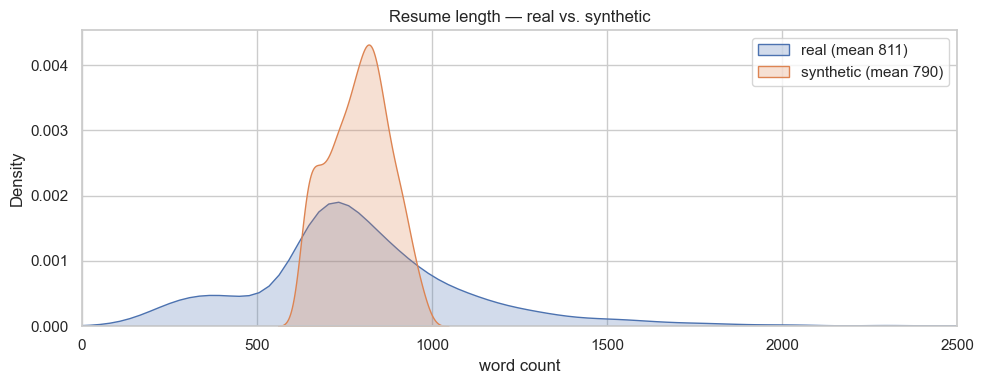

Mean difference: 21 words (2.6% of the real mean)


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(real_words, label=f"real (mean {real_words.mean():.0f})", fill=True, ax=ax)
sns.kdeplot(synthetic_words, label=f"synthetic (mean {synthetic_words.mean():.0f})", fill=True, ax=ax)
ax.set_xlabel("word count")
ax.set_xlim(0, 2500)
ax.set_title("Resume length — real vs. synthetic")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean difference: {abs(real_words.mean() - synthetic_words.mean()):.0f} words "
      f"({abs(real_words.mean() - synthetic_words.mean()) / real_words.mean():.1%} of the real mean)")

## 5. Merge

Rows are shuffled so any ordering artifact (all synthetic rows last) can't influence a later split that isn't explicitly randomized.

Note the `source` column is carried through — notebook 02 uses it to report real-only vs. synthetic-only accuracy, which is the honest way to read the results.

In [8]:
merged_df = pd.concat([real_df, synthetic_df], ignore_index=True)
merged_df = merged_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Merged: {len(merged_df)} rows, {merged_df['Category'].nunique()} categories\n")
print(merged_df["source"].value_counts().to_string())
merged_df.head(3)

Merged: 3634 rows, 34 categories

source
real         2484
synthetic    1150


,Resume_str,Category,source
0,MEDIA ACTIVITIES SPECIALIST Sum...,DIGITAL-MEDIA,real
1,WEBSITE DESIGNER Summary ...,DESIGNER,real
2,GENERAL MANAGER Summary ...,FITNESS,real


## 6. Export

Deliberately exported **raw** — no cleaning, deduplication, or outlier removal happens here. Those are EDA-driven decisions and belong in notebook 02, where each one can be measured and explained before it's applied. Cleaning here would hide from the EDA exactly the problems the EDA is supposed to find.

In [9]:
merged_df.to_csv(OUTPUT_CSV, index=False)
size_mb = OUTPUT_CSV.stat().st_size / 1e6
print(f"Written {OUTPUT_CSV} ({size_mb:.1f} MB)")

# Round-trip check: reload and confirm nothing was lost or mangled.
reloaded = pd.read_csv(OUTPUT_CSV)
assert len(reloaded) == len(merged_df), "row count changed on round trip"
assert set(reloaded.columns) == {"Resume_str", "Category", "source"}, "columns changed"
assert reloaded["Category"].nunique() == merged_df["Category"].nunique(), "categories changed"
print(f"Round-trip OK — {len(reloaded)} rows, {reloaded['Category'].nunique()} categories, "
      f"columns {list(reloaded.columns)}")

Written C:\Users\Asus Vivobook\Resume_parsing\backend\ml\data\merged_resumes.csv (22.5 MB)


Round-trip OK — 3634 rows, 34 categories, columns ['Resume_str', 'Category', 'source']


## 7. Summary

| | Rows | Classes |
|---|---|---|
| Real (industry labels) | 2,484 | 24 |
| Synthetic (tech roles) | 1,150 | 10 |
| **Merged** | **3,634** | **34** |

**Next:** open `02_train_classifier.ipynb`, which loads this CSV and performs EDA → cleaning → feature engineering → model comparison → tuning → evaluation → artifact export.

**Reproducibility:** every random draw here is seeded from `RANDOM_STATE = 42`, so re-running produces a byte-identical CSV.